# Carbon Stock Baseline RF — No RFE
Quick baseline to see raw model performance before RFE.
All features included. 4 models: 1m/full x all-tiers/tier12.


In [1]:
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error
import warnings; warnings.filterwarnings('ignore')

BASE_M   = '/scratch.global/ocon0444/peat_modeling'
CSV_PATH = f'{BASE_M}/00_data/processed/carbon_stock_features_extracted.csv'
PROB_THRESH  = 0.33
N_FOLDS      = 5
RANDOM_STATE = 42
N_TREES      = 100  # lighter for speed

df = pd.read_csv(CSV_PATH, low_memory=False)
print(f'Loaded: {df.shape}')
print(f'Columns with exp416/exp426: '
      f'{[c for c in df.columns if c.startswith("exp4")]}')


Loaded: (3828, 113)
Columns with exp416/exp426: ['exp410_prob', 'exp416_depth_cm', 'exp426_fibric_pct', 'exp426_hemic_pct', 'exp426_sapric_pct']


In [2]:
# Cell 2 — Load data, merge pedon metadata, define features
ID     = 'DNR Peat Inventory ID #'
BASE_M = '/scratch.global/ocon0444/peat_modeling'
BASE_I = '/scratch.global/ocon0444/peat_inventory'

feat_df = pd.read_csv(f'{BASE_M}/00_data/processed/carbon_stock_features_extracted.csv',
                      low_memory=False)
print(f'Extracted features: {feat_df.shape}')
print(f'exp4 columns: {[c for c in feat_df.columns if c.startswith("exp4")]}')

# Load pedon metadata and compute gap_fill_tier
pedon = pd.read_csv(f'{BASE_I}/02_outputs/carbon_stock_pedon.csv', low_memory=False)

def assign_tier(rf_pct):
    if pd.isna(rf_pct): return 'Unknown'
    if rf_pct == 0:     return 'Tier 1 (no RF)'
    if rf_pct <= 50:    return 'Tier 2 (some RF)'
    return 'Tier 3 (majority RF)'

pedon['gap_fill_tier'] = pedon['soc_rf_pct'].apply(assign_tier)
print(f'\nTier counts:\n{pedon["gap_fill_tier"].value_counts().to_string()}')

# Drop conflicting columns before merging
PEDON_COLS = [ID, 'criteria_A', 'criteria_B', 'gap_fill_tier',
              'C_stock_1m_kgm2', 'C_stock_full_kgm2', 'soc_rf_pct']
for col in PEDON_COLS:
    if col != ID and col in feat_df.columns:
        feat_df = feat_df.drop(columns=[col])

df = feat_df.merge(pedon[PEDON_COLS], on=ID, how='inner')
print(f'\nMerged df: {df.shape}')

# Fix dist_from_waterbody_edge_10m — NaN means far from water, not missing
if 'dist_from_waterbody_edge_10m' in df.columns:
    n_nan = df['dist_from_waterbody_edge_10m'].isna().sum()
    df['dist_from_waterbody_edge_10m'] = \
        df['dist_from_waterbody_edge_10m'].fillna(99999)
    print(f'Filled {n_nan:,} NaN in dist_from_waterbody_edge with 99999')

# Define feature columns — exclude all metadata and target columns
NON_FEAT = [
    ID, 'County Name', 'Peatland Name', 'Peatland Classification',
    'UTM_E83', 'UTM_N83', 'UTM_Z83',
    'criteria_A', 'criteria_B',
    'C_stock_1m_kgm2', 'C_stock_full_kgm2',
    'C_stock_1m_MgCha', 'C_stock_full_MgCha',
    'n_horizons_1m', 'n_horizons_full', 'n_horizons_total',
    'max_depth_cm', 'max_peat_depth_cm',
    'soc_measured_pct', 'soc_ash_pct', 'soc_rf_pct',
    'bd_measured_pct', 'bd_ash_pct', 'bd_rf_pct',
    'flag_high_soc_rf', 'flag_high_bd_rf',
    'x_5070', 'y_5070', 'exp410_prob',
    'gap_fill_tier', 'mn_nwi_cowardin_raw',
    'exp416_depth_cm',
    'exp426_fibric_pct', 'exp426_hemic_pct', 'exp426_sapric_pct',
]
LEAKER_PREFIXES = ['histosols', 'npc_peatland', 'MN_organic', 'MN_ANY', 'gNATSGO']

base_features = [
    c for c in df.columns
    if c not in NON_FEAT
    and not any(c.startswith(p) for p in LEAKER_PREFIXES)
    and df[c].dtype in [np.float64, np.float32, np.int64, np.int32, float, int]
]

# Drop features with >50% NaN
nan_pcts  = df[base_features].isna().mean()
bad_feats = nan_pcts[nan_pcts > 0.50].index.tolist()
if bad_feats:
    print(f'Dropping {len(bad_feats)} features >50% NaN: {bad_feats}')
    base_features = [f for f in base_features if f not in bad_feats]

feats_1 = base_features + [c for c in
    ['exp426_fibric_pct', 'exp426_hemic_pct', 'exp426_sapric_pct']
    if c in df.columns]
feats_2 = base_features + [c for c in
    ['exp416_depth_cm'] if c in df.columns]

print(f'\nBase features:                          {len(base_features)}')
print(f'Model 1 features (1m + composition):   {len(feats_1)}')
print(f'Model 2 features (full stock + depth):  {len(feats_2)}')

# Build datasets
peat_mask = df['exp410_prob'] >= PROB_THRESH
TIER12    = ['Tier 1 (no RF)', 'Tier 2 (some RF)']

df1    = df[peat_mask & df['C_stock_1m_kgm2'].notna()].dropna(subset=feats_1).copy()
df1_hq = df1[df1['gap_fill_tier'].isin(TIER12)].copy()
df2    = df[peat_mask & (df['criteria_B']==True) & df['C_stock_full_kgm2'].notna()].dropna(subset=feats_2).copy()
df2_hq = df2[df2['gap_fill_tier'].isin(TIER12)].copy()

datasets = [
    ('1m stock — all tiers',       df1,    feats_1, 'C_stock_1m_kgm2',   'steelblue'),
    ('1m stock — Tier 1+2 only',   df1_hq, feats_1, 'C_stock_1m_kgm2',   '#1a5276'),
    ('Full stock — all tiers',     df2,    feats_2, 'C_stock_full_kgm2', 'green'),
    ('Full stock — Tier 1+2 only', df2_hq, feats_2, 'C_stock_full_kgm2', '#1e8449'),
]
for title, dset, feats, target, _ in datasets:
    y = dset[target].values
    if len(y) == 0:
        print(f'{title}: n=0 — will be skipped')
    else:
        print(f'{title}: n={len(dset):,}  mean={y.mean():.1f}  std={y.std():.1f} kgC/m2')

Extracted features: (3828, 113)
exp4 columns: ['exp410_prob', 'exp416_depth_cm', 'exp426_fibric_pct', 'exp426_hemic_pct', 'exp426_sapric_pct']

Tier counts:
gap_fill_tier
Tier 3 (majority RF)    3123
Tier 1 (no RF)           503
Tier 2 (some RF)         202

Merged df: (3828, 114)
Filled 3,811 NaN in dist_from_waterbody_edge with 99999

Base features:                          74
Model 1 features (1m + composition):   77
Model 2 features (full stock + depth):  75
1m stock — all tiers: n=3,728  mean=57.2  std=14.0 kgC/m2
1m stock — Tier 1+2 only: n=685  mean=59.5  std=17.5 kgC/m2
Full stock — all tiers: n=1,552  mean=123.3  std=64.6 kgC/m2
Full stock — Tier 1+2 only: n=325  mean=143.1  std=61.9 kgC/m2


In [3]:
# Cell 3 — Run baseline CV
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
results = []

for title, dset, feats, target, color in datasets:
    X = dset[feats].values
    y = dset[target].values
    
    if len(y) < N_FOLDS:
        print(f'SKIPPING {title} — only {len(y)} samples (need >={N_FOLDS})')
        continue
    
    print(f'Running: {title} (n={len(y):,}, features={len(feats)})...')
    oof = np.zeros(len(y))
    importances = np.zeros(len(feats))
    for tr_idx, va_idx in kf.split(X):
        rf = RandomForestRegressor(n_estimators=N_TREES, n_jobs=-1,
                                    random_state=RANDOM_STATE)
        rf.fit(X[tr_idx], y[tr_idx])
        oof[va_idx] = rf.predict(X[va_idx])
        importances += rf.feature_importances_
    r2  = r2_score(y, oof)
    mae = mean_absolute_error(y, oof)
    print(f'  R2={r2:.4f}  MAE={mae:.2f} kgC/m2  MAE/mean={100*mae/y.mean():.1f}%')
    results.append({
        'title': title, 'y': y, 'oof': oof,
        'r2': r2, 'mae': mae, 'color': color,
        'feats': feats, 'importances': importances/N_FOLDS,
    })
    print()

print(f'\n{len(results)} models completed successfully.')


Running: 1m stock — all tiers (n=3,728, features=77)...
  R2=0.1694  MAE=8.93 kgC/m2  MAE/mean=15.6%

Running: 1m stock — Tier 1+2 only (n=685, features=77)...
  R2=0.2585  MAE=11.56 kgC/m2  MAE/mean=19.4%

Running: Full stock — all tiers (n=1,552, features=75)...
  R2=0.3043  MAE=40.16 kgC/m2  MAE/mean=32.6%

Running: Full stock — Tier 1+2 only (n=325, features=75)...
  R2=0.2387  MAE=41.81 kgC/m2  MAE/mean=29.2%


4 models completed successfully.


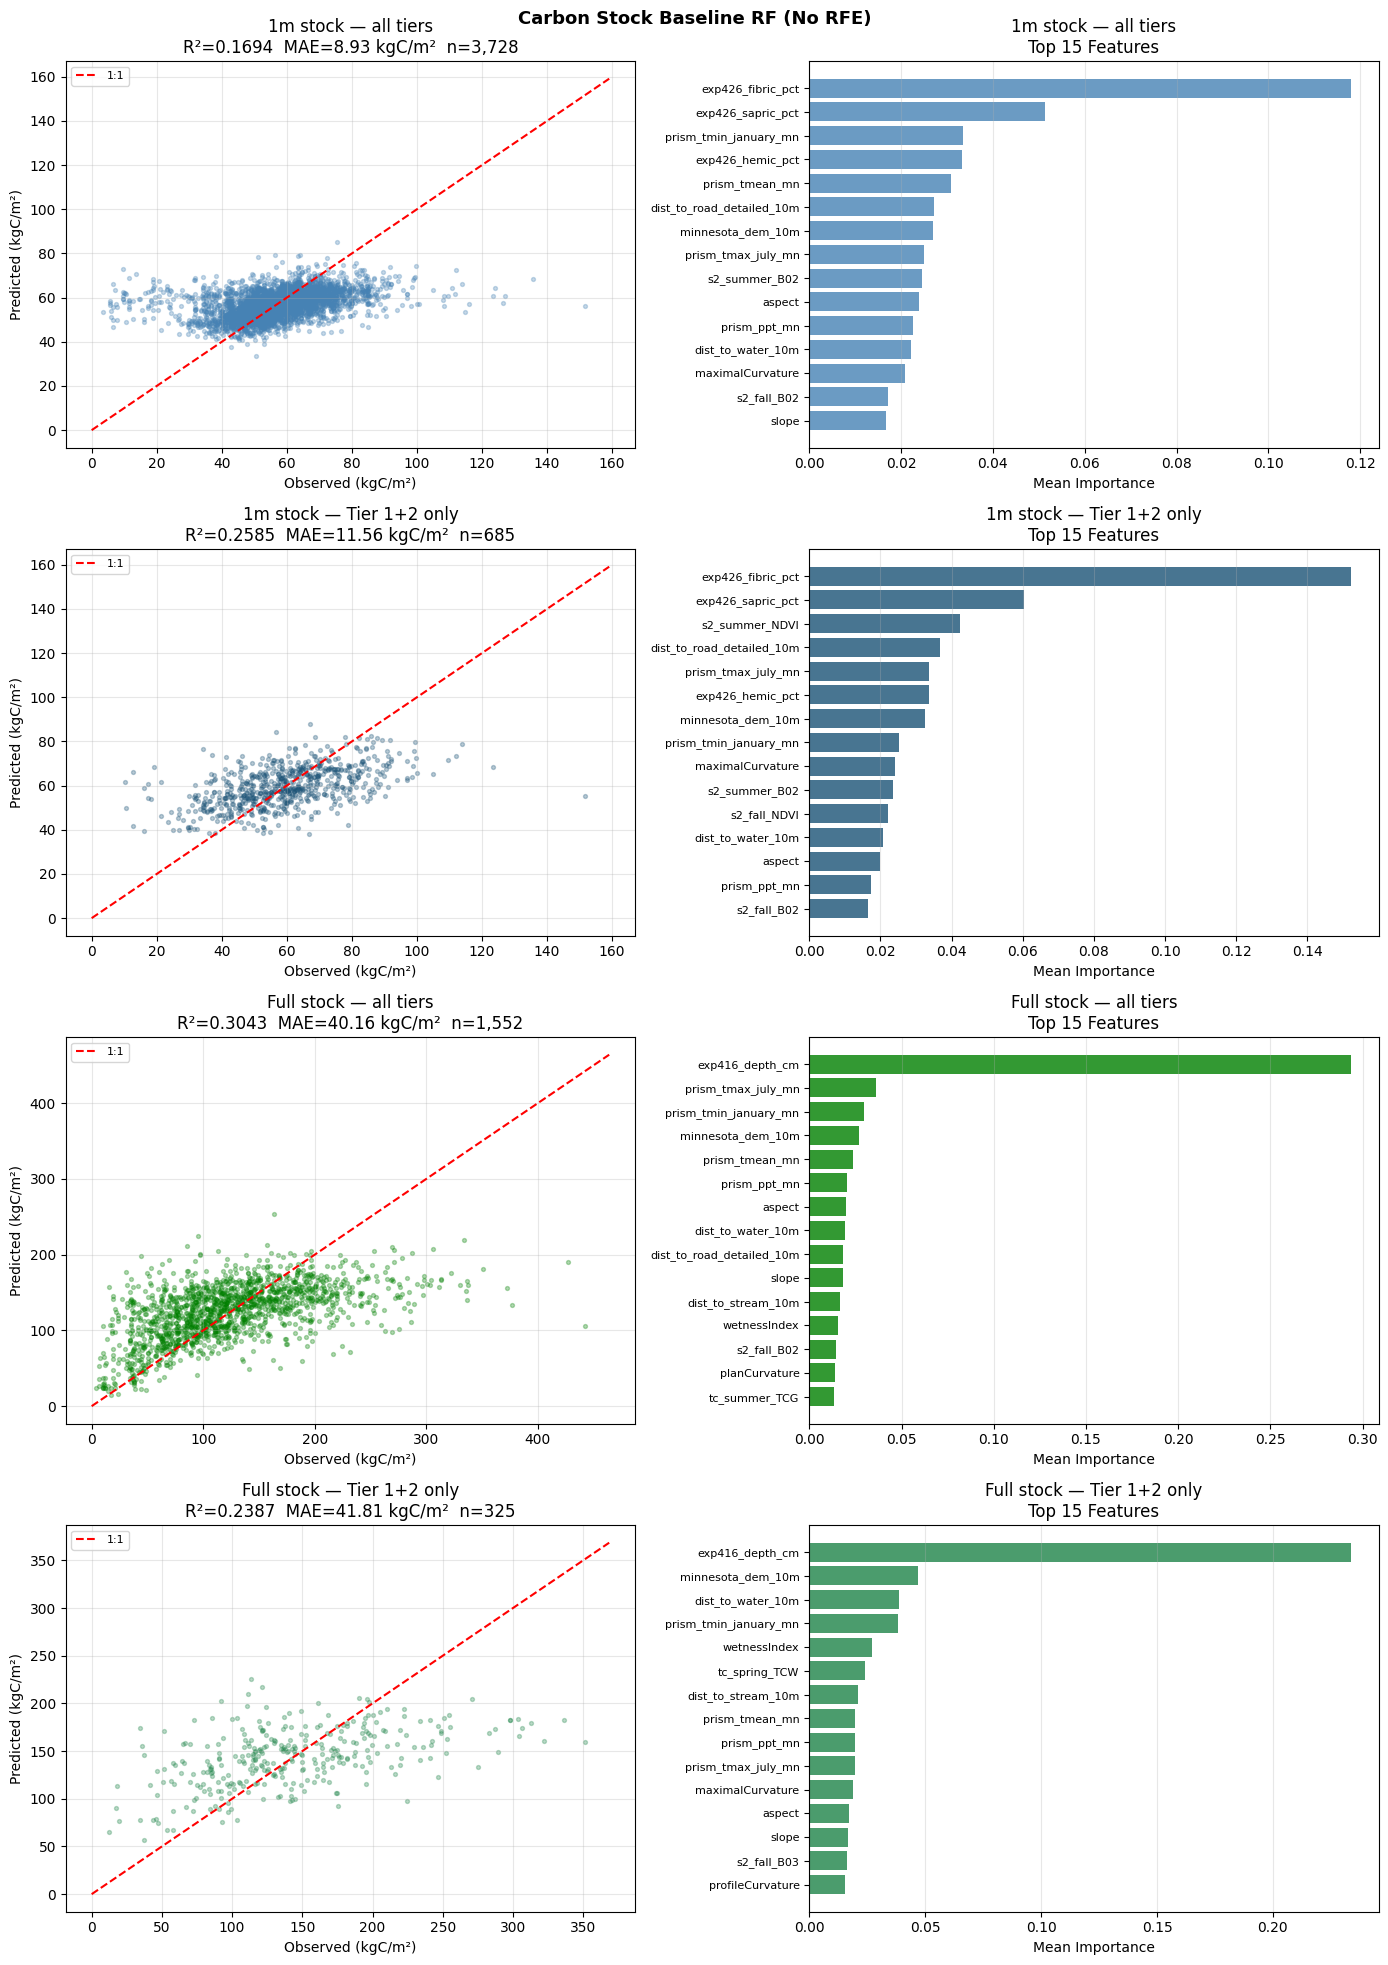

In [4]:
# Results plots
fig, axes = plt.subplots(4, 2, figsize=(14, 20))

for i, res in enumerate(results):
    y, oof = res['y'], res['oof']
    color  = res['color']

    # Predicted vs observed
    ax = axes[i, 0]
    ax.scatter(y, oof, alpha=0.3, s=8, color=color)
    lim = [0, max(y.max(), oof.max())*1.05]
    ax.plot(lim, lim, 'r--', lw=1.5, label='1:1')
    ax.set_xlabel('Observed (kgC/m²)')
    ax.set_ylabel('Predicted (kgC/m²)')
    ax.set_title(f'{res["title"]}\n'
                  f'R²={res["r2"]:.4f}  MAE={res["mae"]:.2f} kgC/m²  n={len(y):,}')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Top 15 feature importance
    ax = axes[i, 1]
    fi = pd.DataFrame({'feature': res['feats'],
                        'importance': res['importances']})\
           .sort_values('importance', ascending=False).head(15)
    ax.barh(range(len(fi)), fi['importance'].values[::-1],
             color=color, alpha=0.8)
    ax.set_yticks(range(len(fi)))
    ax.set_yticklabels([f[:35] for f in fi['feature'].values[::-1]], fontsize=8)
    ax.set_xlabel('Mean Importance')
    ax.set_title(f'{res["title"]}\nTop 15 Features')
    ax.grid(alpha=0.3, axis='x')

plt.suptitle('Carbon Stock Baseline RF (No RFE)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_M}/05_results/exp_carbon_stock/baseline_no_rfe.png',
             dpi=150, bbox_inches='tight')
plt.show()


In [5]:
# Summary table
print('='*65)
print('BASELINE SUMMARY (no RFE)')
print('='*65)
rows = []
for res in results:
    rows.append({
        'Model':           res['title'],
        'n':               len(res['y']),
        'Features':        len(res['feats']),
        'R2':              round(res['r2'], 4),
        'MAE (kgC/m2)':   round(res['mae'], 2),
        'Target mean':     round(res['y'].mean(), 1),
        'MAE/mean %':      round(100*res['mae']/res['y'].mean(), 1),
    })
print(pd.DataFrame(rows).to_string(index=False))
print()
print('If Tier 1+2 R2 >> all-tiers R2: target quality is limiting performance')
print('If similar: covariates are the bottleneck')
print()
print('Top 5 features (1m stock all tiers):')
fi = pd.DataFrame({'f': results[0]['feats'],
                    'i': results[0]['importances']})\
       .sort_values('i', ascending=False).head(5)
for _, row in fi.iterrows():
    print(f'  {row["f"]}: {row["i"]:.4f}')

BASELINE SUMMARY (no RFE)
                     Model    n  Features     R2  MAE (kgC/m2)  Target mean  MAE/mean %
      1m stock — all tiers 3728        77 0.1694          8.93         57.2        15.6
  1m stock — Tier 1+2 only  685        77 0.2585         11.56         59.5        19.4
    Full stock — all tiers 1552        75 0.3043         40.16        123.3        32.6
Full stock — Tier 1+2 only  325        75 0.2387         41.81        143.1        29.2

If Tier 1+2 R2 >> all-tiers R2: target quality is limiting performance
If similar: covariates are the bottleneck

Top 5 features (1m stock all tiers):
  exp426_fibric_pct: 0.1181
  exp426_sapric_pct: 0.0513
  prism_tmin_january_mn: 0.0335
  exp426_hemic_pct: 0.0333
  prism_tmean_mn: 0.0308


In [16]:
# Find the actual column killing dropna
sub = df[peat_mask & df['C_stock_1m_kgm2'].notna()].copy()
print(f'Starting rows: {len(sub):,}')
surviving = len(sub)
for feat in base_features:
    n = sub.dropna(subset=[feat]).shape[0]
    if n < surviving * 0.5:  # drops more than half
        print(f'  CULPRIT: {feat}  survivors={n:,}  NaN%={sub[feat].isna().mean()*100:.1f}%')
    surviving = min(surviving, n)

Starting rows: 3,732
  CULPRIT: C_stock_full_MgCha  survivors=1,551  NaN%=58.4%
  CULPRIT: dist_from_waterbody_edge_10m  survivors=17  NaN%=99.5%
